In this example, we simulate a scenario where we monitor equipment health using:
- **Time series data**: Vibration sensor readings over time
- **Image data**: Thermal camera images of the equipment

We'll classify equipment into three states: **Normal**, **Warning**, and **Critical**.

### Loading Packages

In [10]:
# | code-fold: true

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sktime.classification.interval_based import TimeSeriesForestClassifier
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(1337)
torch.manual_seed(1337)

### Data Generation

We will simulate 500 equipment monitoring samples to demonstrate the value of multimodal fusion:

- A vibration time series (80 time steps)
- A thermal image (32x32 pixels)
- A health status label (0=Normal, 1=Warning, 2=Critical)

**Key challenge**: Some warning cases have ambiguous single-modality signals:

- **Type A**: High vibration (looks critical) but moderate temperature → actually warning
- **Type B**: Low vibration (looks normal) but elevated temperature → actually warning

In [11]:
# | code-fold: true


def generate_synthetic_data(n_samples=500, ts_length=80, img_size=(32, 32)):
    """
    Generate synthetic multimodal data for equipment monitoring.

    This function creates ambiguous data where each modality alone is insufficient,
    but combining both provides better classification. Two types of issues are simulated:
    - Type A: High vibration (looks critical) but low temperature (actually warning)
    - Type B: Low vibration (looks normal) but high temperature (actually warning)

    Returns:
        time_series: vibration sensor data (n_samples, ts_length)
        images: thermal camera data (n_samples, img_size[0], img_size[1])
        labels: equipment health status (n_samples,)
    """
    time_series = []
    images = []
    labels = []

    for _ in range(n_samples):
        # Randomly assign a health status Normal, Warning, Critical
        label = np.random.choice([0, 1, 2], p=[0.45, 0.40, 0.15])
        labels.append(label)

        ambiguous_type = None

        if label == 1 and np.random.random() < 0.85:
            ambiguous_type = np.random.choice(["A", "B"])
        elif label == 0 and np.random.random() < 0.40:
            ambiguous_type = "slight_elevation"  # Many normals look elevated
        elif label == 2 and np.random.random() < 0.35:
            ambiguous_type = (
                "one_misleading"  # Many criticals look normal in one modality
            )

        # Generate time series with high overlap - amplitude and frequency ranges heavily overlap
        if label == 0:  # Normal
            if ambiguous_type == "slight_elevation":
                # Overlaps strongly with warning
                t = np.linspace(0, np.random.uniform(5, 8) * np.pi, ts_length)
                ts = np.random.uniform(1.2, 1.6) * np.sin(t) + np.random.normal(
                    0, 0.5, ts_length
                )
                base_temp = 25 + np.random.normal(0, 7)
            else:
                t = np.linspace(0, np.random.uniform(4, 7) * np.pi, ts_length)
                ts = np.random.uniform(0.8, 1.3) * np.sin(t) + np.random.normal(
                    0, 0.5, ts_length
                )
                base_temp = 22 + np.random.normal(0, 8)
        elif label == 1:  # Warning - extremely ambiguous in time series
            if ambiguous_type == "A":
                # Type A: Looks critical in vibration but moderate temperature
                t = np.linspace(0, np.random.uniform(9, 12) * np.pi, ts_length)
                ts = np.random.uniform(1.8, 2.3) * np.sin(t) + np.random.normal(
                    0, 0.6, ts_length
                )
                # Add spikes that make it look critical
                spike_indices = np.random.choice(
                    ts_length, size=np.random.randint(3, 6), replace=False
                )
                ts[spike_indices] += np.random.uniform(1, 2.5, size=len(spike_indices))
                base_temp = 40 + np.random.normal(
                    0, 9
                )  # Moderate temp distinguishes it
            elif ambiguous_type == "B":
                # Type B: Looks normal in vibration but elevated temperature
                t = np.linspace(0, np.random.uniform(4, 7) * np.pi, ts_length)
                ts = np.random.uniform(1.0, 1.4) * np.sin(t) + np.random.normal(
                    0, 0.5, ts_length
                )
                base_temp = 52 + np.random.normal(0, 9)  # High temp distinguishes it
            else:
                # Regular warning - still overlaps with both normal and critical
                t = np.linspace(0, np.random.uniform(6, 9) * np.pi, ts_length)
                ts = np.random.uniform(1.3, 1.8) * np.sin(t) + np.random.normal(
                    0, 0.6, ts_length
                )
                base_temp = 43 + np.random.normal(0, 10)
        else:  # Critical
            if ambiguous_type == "one_misleading":
                # One modality looks much less critical
                if np.random.random() < 0.5:
                    # Lower vibration (overlaps with warning/normal) but very high temp
                    t = np.linspace(0, np.random.uniform(6, 9) * np.pi, ts_length)
                    ts = np.random.uniform(1.4, 1.9) * np.sin(t) + np.random.normal(
                        0, 0.6, ts_length
                    )
                    spike_indices = np.random.choice(
                        ts_length, size=np.random.randint(1, 3), replace=False
                    )
                    ts[spike_indices] += np.random.uniform(
                        0.5, 1.5, size=len(spike_indices)
                    )
                    base_temp = 70 + np.random.normal(
                        0, 8
                    )  # Temperature is clearly critical
                else:
                    # Higher vibration but moderate temp (overlaps with warning)
                    t = np.linspace(0, np.random.uniform(10, 13) * np.pi, ts_length)
                    ts = np.random.uniform(1.9, 2.3) * np.sin(t) + np.random.normal(
                        0, 0.7, ts_length
                    )
                    spike_indices = np.random.choice(
                        ts_length, size=np.random.randint(4, 7), replace=False
                    )
                    ts[spike_indices] += np.random.uniform(
                        1.5, 3, size=len(spike_indices)
                    )
                    base_temp = 58 + np.random.normal(0, 8)  # Moderate temp
            else:
                # More typical critical but with variability
                t = np.linspace(0, np.random.uniform(10, 14) * np.pi, ts_length)
                ts = np.random.uniform(1.8, 2.4) * np.sin(t) + np.random.normal(
                    0, 0.7, ts_length
                )
                spike_indices = np.random.choice(
                    ts_length, size=np.random.randint(4, 8), replace=False
                )
                ts[spike_indices] += np.random.uniform(
                    1.5, 3.5, size=len(spike_indices)
                )
                base_temp = 68 + np.random.normal(0, 10)

        time_series.append(ts)

        # Generate thermal image with HIGH ambiguity to make classification harder
        # Much more overlap between classes to reduce image-only accuracy
        img = np.random.normal(base_temp, 15, img_size)  # Even higher noise

        # Add hot spots with heavily overlapping patterns to create strong ambiguity
        if label == 0:  # Normal - but frequently looks like warning or critical
            if np.random.random() < 0.55:
                # Often looks like warning or critical
                n_hotspots = np.random.randint(2, 4)
                hotspot_intensity_factor = np.random.uniform(1.0, 1.8)
                hotspot_base = 18
            else:
                n_hotspots = np.random.randint(1, 3)
                hotspot_intensity_factor = np.random.uniform(0.7, 1.3)
                hotspot_base = 12
        elif label == 1:  # Warning - highly ambiguous, overlaps heavily with both
            if np.random.random() < 0.45:
                # Looks like normal
                n_hotspots = np.random.randint(1, 3)
                hotspot_intensity_factor = np.random.uniform(0.7, 1.3)
                hotspot_base = 14
            elif np.random.random() < 0.45:
                # Looks like critical
                n_hotspots = np.random.randint(2, 4)
                hotspot_intensity_factor = np.random.uniform(1.5, 2.2)
                hotspot_base = 28
            else:
                n_hotspots = np.random.randint(2, 3)
                hotspot_intensity_factor = np.random.uniform(1.0, 1.6)
                hotspot_base = 20
        else:  # Critical - but often looks like warning or normal
            if np.random.random() < 0.50:
                # Frequently looks like warning or normal
                n_hotspots = np.random.randint(2, 3)
                hotspot_intensity_factor = np.random.uniform(1.1, 1.7)
                hotspot_base = 22
            else:
                n_hotspots = np.random.randint(2, 4)
                hotspot_intensity_factor = np.random.uniform(1.6, 2.4)
                hotspot_base = 30

        for _ in range(n_hotspots):
            x, y = (
                np.random.randint(6, img_size[0] - 6),
                np.random.randint(6, img_size[1] - 6),
            )
            intensity = (
                hotspot_base + np.random.uniform(5, 25) * hotspot_intensity_factor
            )  # More variable intensity
            # Create a Gaussian hot spot with more variable size
            sigma = np.random.uniform(2.0, 7.0)  # Wider range for hotspot size
            xx, yy = np.meshgrid(np.arange(img_size[0]), np.arange(img_size[1]))
            hotspot = intensity * np.exp(
                -((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma**2)
            )
            img += hotspot.T

        images.append(img)

    return np.array(time_series), np.array(images), np.array(labels)


# Generate data
ts_data, img_data, labels = generate_synthetic_data()

print(f"Time series shape: {ts_data.shape}")
print(f"Images shape: {img_data.shape}")
print(f"Labels shape: {labels.shape}")
print()
print("Class distribution:")
print(
    f"  Normal: {np.sum(labels == 0)} ({np.sum(labels == 0) / len(labels) * 100:.1f}%)"
)
print(
    f"  Warning: {np.sum(labels == 1)} ({np.sum(labels == 1) / len(labels) * 100:.1f}%)"
)
print(
    f"  Critical: {np.sum(labels == 2)} ({np.sum(labels == 2) / len(labels) * 100:.1f}%)"
)

Time series shape: (500, 80)
Images shape: (500, 32, 32)
Labels shape: (500,)

Class distribution:
  Normal: 222 (44.4%)
  Critical: 74 (14.8%)


### Visualization

Let us visualize examples from each health status class:

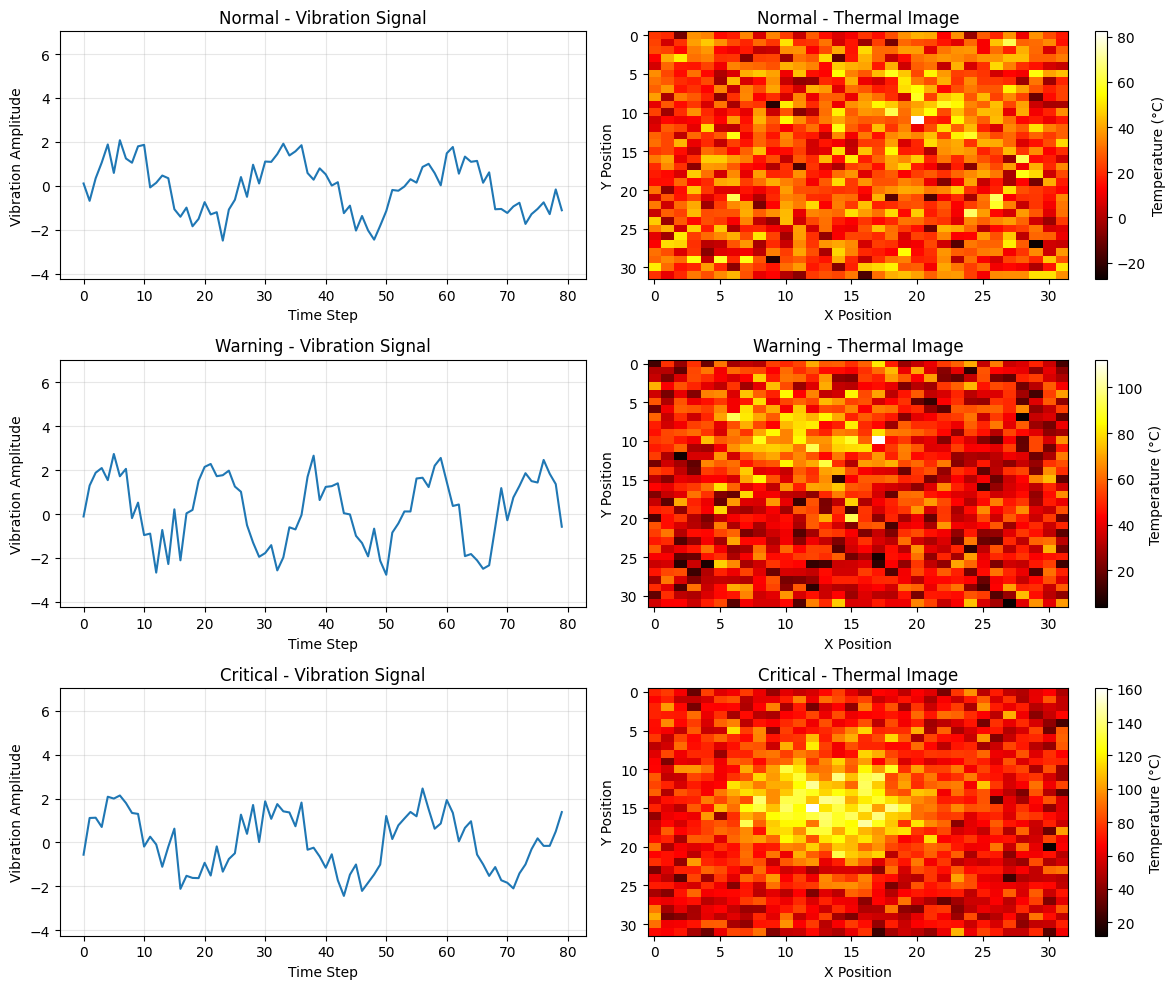

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
status_names = ["Normal", "Warning", "Critical"]

for status in range(3):
    # Find first sample of this status
    idx = np.where(labels == status)[0][0]

    # Plot time series
    axes[status, 0].plot(ts_data[idx])
    axes[status, 0].set_title(f"{status_names[status]} - Vibration Signal")
    axes[status, 0].set_ylim(ts_data.min(), ts_data.max())
    axes[status, 0].set_xlabel("Time Step")
    axes[status, 0].set_ylabel("Vibration Amplitude")
    axes[status, 0].grid(True, alpha=0.3)

    # Plot thermal image
    im = axes[status, 1].imshow(img_data[idx], cmap="hot", aspect="auto")
    axes[status, 1].set_title(f"{status_names[status]} - Thermal Image")
    axes[status, 1].set_xlabel("X Position")
    axes[status, 1].set_ylabel("Y Position")
    plt.colorbar(im, ax=axes[status, 1], label="Temperature (°C)")

plt.tight_layout()
plt.show()

### Train-Test Split

We split the data into training (80%) and testing (20%) sets:

In [13]:
# Split data
ts_train, ts_test, img_train, img_test, y_train, y_test = train_test_split(
    ts_data, img_data, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set: {len(ts_train)} samples")
print(f"Test set: {len(ts_test)} samples")

Training set: 400 samples
Test set: 100 samples


### Model 1: Time Series Classifier

We will use a Random Forest on extracted time series features (mean, std, min, max, etc.):

In [14]:
# Reshape time series for sktime format (n_samples, n_features, n_timesteps)
# sktime expects 3D input where the middle dimension is the number of features (variables)
# Since we have univariate time series, n_features = 1
X_train_ts = ts_train.reshape(ts_train.shape[0], 1, ts_train.shape[1])
X_test_ts = ts_test.reshape(ts_test.shape[0], 1, ts_test.shape[1])

# Train Time Series Forest Classifier
print("Training Time Series Model...")
tsf = TimeSeriesForestClassifier(n_estimators=50, random_state=42)
tsf.fit(X_train_ts, y_train)

# Predict probabilities
ts_train_probs = tsf.predict_proba(X_train_ts)
ts_test_probs = tsf.predict_proba(X_test_ts)

print("Time Series Model - Test Set Performance:")
ts_pred = tsf.predict(X_test_ts)
print(
    classification_report(
        y_test, ts_pred, target_names=["Normal", "Warning", "Critical"]
    )
)

Training Time Series Model...
Time Series Model - Test Set Performance:
              precision    recall  f1-score   support

      Normal       0.70      0.89      0.78        44
     Warning       0.65      0.49      0.56        41
    Critical       0.69      0.60      0.64        15

    accuracy                           0.68       100
   macro avg       0.68      0.66      0.66       100
weighted avg       0.67      0.68      0.67       100



### Model 2: Image Classifier

We will use a Convolutional Neural Network (CNN) for the thermal images:

In [15]:
# Normalize images to [0, 1]
img_train_norm = (img_train - img_train.min()) / (img_train.max() - img_train.min())
img_test_norm = (img_test - img_train.min()) / (img_train.max() - img_train.min())

# Reshape for CNN - PyTorch uses (batch, channels, height, width)
img_train_cnn = img_train_norm.reshape(-1, 1, 32, 32)
img_test_cnn = img_test_norm.reshape(-1, 1, 32, 32)


# Define simpler CNN model in PyTorch
class ThermalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(32, 32)
        self.fc2 = nn.Linear(32, 3)
        self.dropout = nn.Dropout(0.4)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Initialize model, loss, and optimizer
device = torch.device("cpu")
model_img = ThermalCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_img.parameters(), lr=0.001)

# Prepare data loaders
train_dataset = TensorDataset(
    torch.FloatTensor(img_train_cnn), torch.LongTensor(y_train)
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = TensorDataset(torch.FloatTensor(img_test_cnn), torch.LongTensor(y_test))
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Training loop with fewer epochs
print("Training Image Model...")
model_img.train()
for epoch in range(20):  # Reduced from 30 to 20 epochs
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_img(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

# Get predictions
model_img.eval()
with torch.no_grad():
    # Training set predictions
    img_train_probs = []
    for images, _ in DataLoader(train_dataset, batch_size=16, shuffle=False):
        images = images.to(device)
        outputs = model_img(images)
        probs = torch.softmax(outputs, dim=1)
        img_train_probs.append(probs.cpu().numpy())
    img_train_probs = np.vstack(img_train_probs)

    # Test set predictions
    img_test_probs = []
    img_preds = []
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model_img(images)
        probs = torch.softmax(outputs, dim=1)
        img_test_probs.append(probs.cpu().numpy())
        img_preds.append(torch.argmax(outputs, dim=1).cpu().numpy())
    img_test_probs = np.vstack(img_test_probs)
    img_pred = np.concatenate(img_preds)

print("\nImage Model - Test Set Performance:")
print(
    classification_report(
        y_test, img_pred, target_names=["Normal", "Warning", "Critical"]
    )
)

Training Image Model...

Image Model - Test Set Performance:
              precision    recall  f1-score   support

      Normal       0.89      0.89      0.89        44
     Warning       0.78      0.76      0.77        41
    Critical       0.69      0.73      0.71        15

    accuracy                           0.81       100
   macro avg       0.78      0.79      0.79       100
weighted avg       0.81      0.81      0.81       100



### Early Fusion: Combining Both Modalities

We build a model that combines both modalities at the input level.

In [16]:
# Define a CNN for images (2D CNN)
class ThermalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(32, 32)
        self.fc2 = nn.Linear(32, 3)
        self.dropout = nn.Dropout(0.4)
        self.relu = nn.ReLU()

    def forward(self, x, features_only=False):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        if features_only:
            return x
        x = self.fc2(x)
        return x


# Define a CNN for time series (1D CNN)
class TimeSeriesCNN(nn.Module):
    def __init__(self, ts_length=80):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc(x))
        x = self.dropout(x)
        return x


# Combined multimodal network
class MultimodalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.img_net = ThermalCNN()
        self.ts_net = TimeSeriesCNN()
        self.fc_combined = nn.Linear(32 + 32, 32)
        self.fc_out = nn.Linear(32, 3)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

    def forward(self, img, ts):
        img_feat = self.img_net(img, features_only=True)
        ts_feat = self.ts_net(ts)
        x = torch.cat([img_feat, ts_feat], dim=1)
        x = self.relu(self.fc_combined(x))
        x = self.dropout(x)
        x = self.fc_out(x)
        return x


# Prepare data for multimodal network
# Normalize and reshape time series for 1D CNN: (batch, channels=1, length)
ts_train_norm = (ts_train - ts_train.min()) / (ts_train.max() - ts_train.min())
ts_test_norm = (ts_test - ts_train.min()) / (ts_train.max() - ts_train.min())

ts_train_cnn = ts_train_norm.reshape(-1, 1, ts_train_norm.shape[1]).astype(np.float32)
ts_test_cnn = ts_test_norm.reshape(-1, 1, ts_test_norm.shape[1]).astype(np.float32)

# Normalize and reshape images for 2D CNN: (batch, channels=1, height, width)
img_train_cnn = img_train_norm.reshape(
    -1, 1, img_train_norm.shape[1], img_train_norm.shape[2]
).astype(np.float32)
img_test_cnn = img_test_norm.reshape(
    -1, 1, img_test_norm.shape[1], img_test_norm.shape[2]
).astype(np.float32)

# Convert to torch tensors
ts_train_tensor = torch.FloatTensor(ts_train_cnn)
ts_test_tensor = torch.FloatTensor(ts_test_cnn)
img_train_tensor = torch.FloatTensor(img_train_cnn)
img_test_tensor = torch.FloatTensor(img_test_cnn)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

# DataLoader for multimodal training
multimodal_train_dataset = TensorDataset(
    img_train_tensor, ts_train_tensor, y_train_tensor
)
multimodal_test_dataset = TensorDataset(img_test_tensor, ts_test_tensor, y_test_tensor)
multimodal_train_loader = DataLoader(
    multimodal_train_dataset, batch_size=16, shuffle=True
)
multimodal_test_loader = DataLoader(
    multimodal_test_dataset, batch_size=16, shuffle=False
)

# Initialize and train the multimodal model
device = torch.device("cpu")
multimodal_model = MultimodalNet().to(device)
optimizer_mm = optim.Adam(multimodal_model.parameters(), lr=0.001)
criterion_mm = nn.CrossEntropyLoss()

print("Training Multimodal Model...")
multimodal_model.train()
for epoch in range(30):
    running_loss = 0.0
    for img_batch, ts_batch, labels_batch in multimodal_train_loader:
        img_batch, ts_batch, labels_batch = (
            img_batch.to(device),
            ts_batch.to(device),
            labels_batch.to(device),
        )
        optimizer_mm.zero_grad()
        outputs = multimodal_model(img_batch, ts_batch)
        loss = criterion_mm(outputs, labels_batch)
        loss.backward()
        optimizer_mm.step()
        running_loss += loss.item()

# Evaluate on test set
multimodal_model.eval()
mm_test_probs = []
mm_test_preds = []
with torch.no_grad():
    for img_batch, ts_batch, _ in multimodal_test_loader:
        img_batch, ts_batch = img_batch.to(device), ts_batch.to(device)
        outputs = multimodal_model(img_batch, ts_batch)
        probs = F.softmax(outputs, dim=1)
        mm_test_probs.append(probs.cpu().numpy())
        mm_test_preds.append(torch.argmax(outputs, dim=1).cpu().numpy())
mm_test_probs = np.vstack(mm_test_probs)
early_fusion_pred = np.concatenate(mm_test_preds)

print("\nMULTIMODAL STACKED MODEL - Test Set Performance:")
print(
    classification_report(
        y_test, early_fusion_pred, target_names=["Normal", "Warning", "Critical"]
    )
)

ts_accuracy = accuracy_score(y_test, ts_pred)
img_accuracy = accuracy_score(y_test, img_pred)
combined_accuracy = accuracy_score(y_test, early_fusion_pred)

print(f"Time Series Only:  {ts_accuracy:.3f}")
print(f"Image Only:        {img_accuracy:.3f}")
print(f"Multimodal Fusion: {combined_accuracy:.3f}")
print(
    f"\nImprovement: {(combined_accuracy - max(ts_accuracy, img_accuracy)) * 100:.1f}% over best single modality"
)

Training Multimodal Model...

MULTIMODAL STACKED MODEL - Test Set Performance:
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.96        44
     Warning       0.92      0.88      0.90        41
    Critical       0.87      0.87      0.87        15

    accuracy                           0.92       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.92      0.92      0.92       100

Time Series Only:  0.680
Image Only:        0.810
Multimodal Fusion: 0.920

Improvement: 11.0% over best single modality


### Late Fusion: Combining Both Modalities

Now we implement a simple late fusion approach that combines the predictions from both unimodal models by averaging their probability outputs:

In [17]:
# Simple late fusion by averaging probabilities from both models
late_fusion_probs = (ts_test_probs + img_test_probs) / 2
late_fusion_pred = np.argmax(late_fusion_probs, axis=1)

print("LATE FUSION MODEL - Test Set Performance:")
print(
    classification_report(
        y_test, late_fusion_pred, target_names=["Normal", "Warning", "Critical"]
    )
)

late_fusion_accuracy = accuracy_score(y_test, late_fusion_pred)
print(f"\nLate Fusion:       {late_fusion_accuracy:.3f}")

LATE FUSION MODEL - Test Set Performance:
              precision    recall  f1-score   support

      Normal       0.95      0.93      0.94        44
     Warning       0.87      0.95      0.91        41
    Critical       1.00      0.80      0.89        15

    accuracy                           0.92       100
   macro avg       0.94      0.89      0.91       100
weighted avg       0.92      0.92      0.92       100


Late Fusion:       0.920


### Confusion Matrices

Let us visualize the confusion matrices for all approaches:

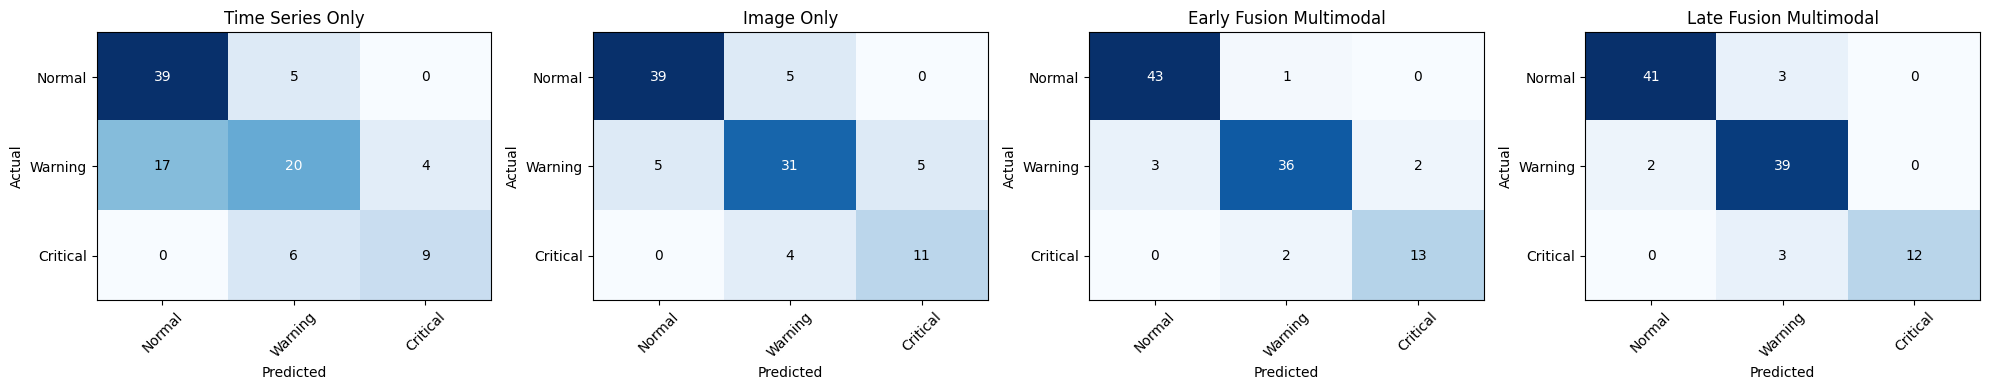


Model Performance Summary:
Time Series Only:     0.680
Image Only:           0.810
Late Fusion:          0.920
Multimodal Network:   0.920


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

models = [
    ("Time Series Only", ts_pred),
    ("Image Only", img_pred),
    ("Early Fusion Multimodal", early_fusion_pred),
    ("Late Fusion Multimodal", late_fusion_pred),
]

for idx, (title, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    im = axes[idx].imshow(cm, cmap="Blues", aspect="auto")
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_xticks([0, 1, 2])
    axes[idx].set_yticks([0, 1, 2])
    axes[idx].set_xticklabels(["Normal", "Warning", "Critical"], rotation=45)
    axes[idx].set_yticklabels(["Normal", "Warning", "Critical"])

    # Add text annotations
    for i in range(3):
        for j in range(3):
            text = axes[idx].text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="black" if cm[i, j] < cm.max() / 2 else "white",
            )

plt.tight_layout()
plt.show()

# Print summary
print("\nModel Performance Summary:")
print(f"Time Series Only:     {accuracy_score(y_test, ts_pred):.3f}")
print(f"Image Only:           {accuracy_score(y_test, img_pred):.3f}")
print(f"Late Fusion:          {late_fusion_accuracy:.3f}")
print(f"Multimodal Network:   {accuracy_score(y_test, early_fusion_pred):.3f}")

The multimodal approaches typically outperform single-modality models, especially when modalities provide complementary information.